# **Health Insurance Data Cleaning and Visualisations**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline
#last code line generated by Gemini to allow matplotlib plots to be seen

## Objectives

* Load insurance.csv dataset from Kaggle.
* Clean and prepare the insurance.csv dataset for exploratory data analysis by checking data types, checking for missing values, and removing duplicate records.  
* Perform Exploratory Data Analysis (EDA) to analyze the impact of individual and combined variables within the dataset on medical charges.
* Create hypotheses to test in order to identify which variables influence cost.  
* Create 2D scatter plots, an interactive 3D plot, side-by-side bar plots, and a summary grid to test hypotheses and communicate analytical findings. 

## Inputs

* insurance.csv (Raw medical insurance dataset containing demographic, physical, and smoking features).

## Outputs

* insurance_cleaned.csv (Cleaned dataset with duplicates removed, ready for visualisations).  
* Diagnostic EDA visualisations (2D scatter plots, interactive 3D scatter plot, side-by-side bar charts, and a multi summary figure)

## Additional Comments
* Working Directory: Includes custom script logic to automatically verify and set the working directory to the root folder.  
* AI Usage Note: Generative AI tools were used to assist with code structure formatting, choosing suitable plots and text refinement for insights.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\world\\OneDrive\\Code Institute\\Health-Insurance-Analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\world\\OneDrive\\Code Institute\\Health-Insurance-Analysis'

# Loading and cleaning the data

Write code to read insurance.csv file and save to the variable df

In [5]:
#code format taken from LMS visualisations modules
df = pd.read_csv('data/raw data/insurance.csv')

Inspect the data: check shape, check data types in each column, look for missing values and duplicates, spot outliers.

Shape Check:

In [6]:
#check how many rows and columns
#code from my notes from Rory's lesson
df.shape

(1338, 7)

In [7]:
#check the first five rows to see if the data loaded correctly
#code from my notes from Rory's lesson
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Data Type Check:

In [8]:
#check the data type in each column to see if there is any rogue text
#code from my notes from Rory's lesson
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Age, BMI, children and charges all have numbers, so no rogue text is present in those columns. We will check for negative numbers later on. Smoker, sex and region are object types, so we need to see which objects they contain to check they are clean.

Run value counts to see what is in each of the columns with object as their data type.

In [9]:
#code taken from Gemini
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [10]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [11]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

The above results show that there are no random values in the 3 object columns we checked.

Missing Values Check:

In [12]:
#check for any missing values
#code from my notes from Rory's lesson
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There are no missing values.

Duplicates Check:

In [13]:
#Gemini suggested chaining to see how many duplicates are present
df.duplicated().sum()

1

There is one duplicate. As charges aand bmi are floats with several decimal places, this could be a duplicate, not just a coincidence. Check the 2 identical rows before deciding whether or not to remove it.

In [14]:
#code generated using Gemini guidance for structure and keep=False
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


Bmi is identical to 2 decimal places and charges is identical down to 4 decimal places! We will treat this as a duplicate and remove the duplicated row.

In [15]:
#save the cleaned version to a new variable
#this code will keep the first instance and drop the second duplicated one. 'drop_duplicates()' was taken from Gemini.
df_cleaned = df.drop_duplicates()

In [16]:
#check the shape to see if one row was dropped
df_cleaned.shape

(1337, 7)

This is the expected output. One row was dropped.

Outlier Check:

In [17]:
#code from my notes in Rory's lesson
df_cleaned.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


From this output we can see that all columns have 1337 rows, confirming the duplicate row was dropped in the second instance and no new rows were added. We can see the mean, minimum and maximum values for all columns. There may be some outliers. The max bmi sits a little further from the 75th percentile and the max charges are much higher than the 75th percentile. These would be our outliers. We could use a box plot to show this. We can also see that the columns with data types int64 and float from earlier do not have any negative numbers. We can conclude that the data looks accurate and is clean.

Save the cleaned data as a csv file

In [18]:
#code taken from Jayne Lawley in Project 1
df_cleaned.to_csv('data/cleaned data/insurance_cleaned.csv', index=False)

# Visualising Charges Outliers

Draw a boxplot for charges to see outliers

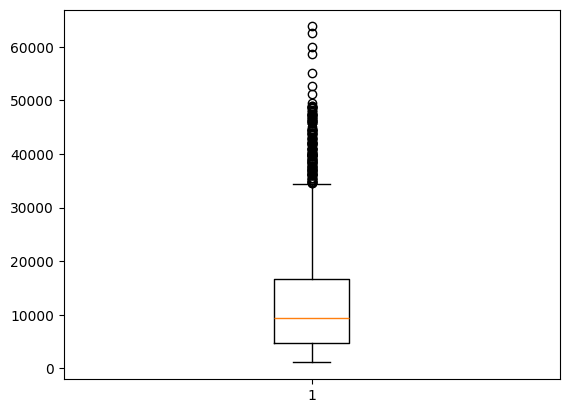

In [19]:
#code structure from LMS modules
plt.boxplot(df_cleaned['charges'])
plt.show()

From this boxplot, we can see that there are a significant number of outliers. We can assume that they are not accidental or typing errors, but rather they represent real data. E.g. one reason for these outlier individuals having higher charges than the majority of people in the dataset could be due to major surgeries. We will not exclude any of these charges for the following charts and analyses as that would be a misrepresentation of the data and lower the charges.  

---

# Visualisations

Hypotheses:

Age: Medical charges increase with age.

Smoking: Patients who smoke have significantly higher medical charges than non-smokers.

BMI: Patients with higher bmi generally have higher medical charges. 

Region & Children: A patient's geographic region and the number of children they have will impact their average medical charges.

### Age vs Charges:

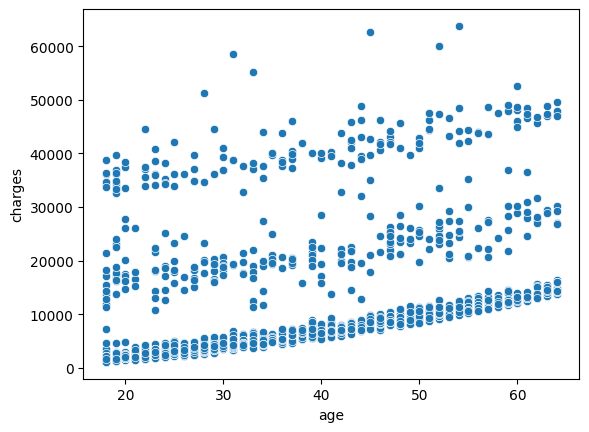

In [20]:
#code structure from LMS modules
sns.scatterplot(data=df_cleaned, x='age', y='charges')
plt.show()

We see 3 distinct bands. Let's see what other variables could be contributing to this.

### Age vs Charges coloured by Smoker:

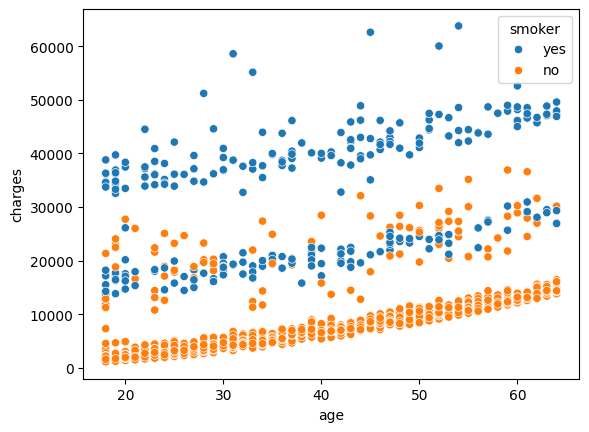

In [21]:
sns.scatterplot(data=df_cleaned, x='age', y='charges', hue='smoker')
plt.show()

We can see that smokers have the highest charges across all ages. The general trend in the smoking and non smoking groups is that insurance costs increase with age.
However, there is still an overlap in many data points for smokers and non smokers. We will explore this later.

In [23]:
#code taken from LMS modules
fig = px.scatter(df_cleaned, x="age", y="charges", color="smoker",
                 marginal_y="box", marginal_x="box")
fig.show()

The marginal box plot on the right confirms that the median charges for smokers is much higher than the median charges for non-smokers. It clearly shows that the lowest charges for smokers is still higher than what half of non-smokers are charged. The top marginal box plot shows us that the distribution of age is quite similar in smokers and non-smokers.

Accross these plots, there are 3 clear cost bands. The lowest band is made up of only non-smokers and the top band is entirely made up of smokers. The middle band has a mixture of both groups. This shows that there is another factor, separate to smoking and age, that drives prices up for both smokers and non-smokers. We will explore the effect of BMI on charges next.

AI Usage Note:
(Generative AI was used to help explore the marginal distributions and refine the language in this insight summary.)

### BMI vs Charges coloured by Smoker:

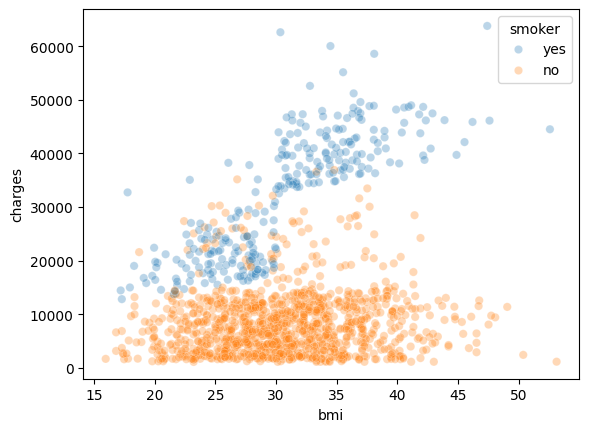

In [73]:
sns.scatterplot(data=df_cleaned, x='bmi', y='charges', hue='smoker', alpha=0.3)
plt.show()

This scatterplot shows that smokers with the same or similar bmi to non smokers have significantly higher medical charges. There is also a difference in pattern in the smokers and non smokers groups. There is a sharp increase in charges when the bmi crosses 30 in smokers, but such a pattern is not seen in the non smokers group where charges stay relatively stable across BMI levels. 

This scatter plot shows that smokers with the same or similar BMI to non-smokers have significantly higher medical charges. There is also a clear difference in pattern between the two groups: there is a sharp increase in charges when BMI crosses 30 in smokers, but non-smoker charges stay relatively stable across all BMI levels.

This jump at a BMI of 30 in smokers explains the top band from our earlier age vs charges plot. Smokers with a BMI under 30 stay in the middle band. However, there is still some overlap in charges in the middle band for smokers and non-smokers.

We will look at how age, BMI and smoking status interact with each other to affect charges.

AI Usage Note:
(Generative AI was used to help explore the marginal distributions and refine the language in this insight summary.)

### BMI vs Age vs Charges coloured by Smoker:

3d scatterplot idea taken from Pete Daniel Smith.
Gemini listed paramenters and px.scatter.
Copilot predictions used in generating code below.

In [ ]:
fig = px.scatter_3d(df_cleaned, x='age', y='bmi', z='charges', color='smoker')
fig.update_layout(scene=dict(
                    xaxis_title='Age',
                    yaxis_title='BMI',
                    zaxis_title='Charges'))
# Gemini used to shrink the marker size to make points less dense
fig.update_traces(marker=dict(size=3))

# Gemini used to increase canvas size
fig.update_layout(
    height=700,
    width=900,
    scene=dict(
        xaxis_title="Age",
        yaxis_title="BMI",
        zaxis_title="Charges",
        aspectratio=dict(x=1.2, y=1.2, z=1.2),  # Expands 3D box dimensions
    ),
)
fig.show()    

Through interacting with this 3D plot, we can clarify the crossovers between the different factors. We saw from previous plots that the bottom band belongs to non-smokers and the top band to smokers, and identified the overlap in the middle band. By interacting with dots in the middle band, we see that low BMI (< 30) is what keeps smokers down in the middle band, preventing them from jumping into the top band.

Among non-smokers in that middle band, some are there due to high BMI despite being young, while others are there due to a combination of higher age and high BMI. However, none of those factors alone push non-smokers into the top band. There are also some non-smokers in the bottom band with similar BMI and age to those in the middle band. The reason for these higher charges could be real-life medical factors like acute illnesses, hospital stays, or surgeries, which are not captured in our dataset. Overall, the general trend shows that high BMI, or a combination of higher BMI and age, drives non-smokers into the middle band.

Next, we will look at other remaining variables to see if there are further correlations or insights. 

AI Note: Generative AI was used as a grammar and language refinement tool to assist in drafting this insight summary based on my visual findings.

### Sex vs Average Charges:

In [ ]:
#code generated with hints and fixes from Gemini
avg_charges = df_cleaned.groupby('sex')['charges'].mean()

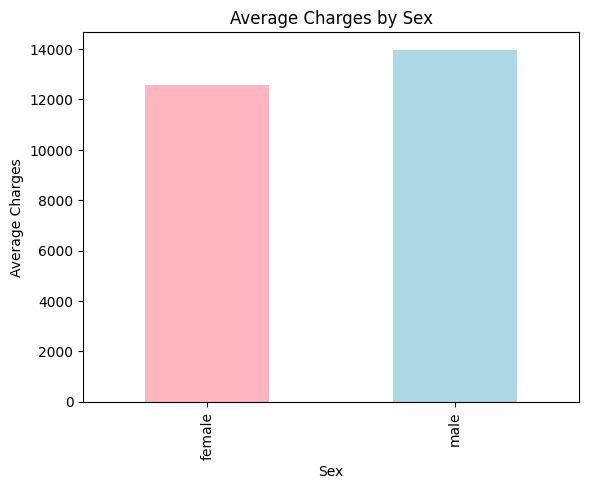

In [65]:
#used copilot suggestions to generate this code and label the graph
avg_charges.plot(kind='bar', color=['lightpink', 'lightblue'])
plt.xlabel('Sex')
plt.ylabel('Average Charges')
plt.title('Average Charges by Sex')
plt.show()

While males on average have slightly higher insurance costs, sex alone is not a big contributor to medical charges. The number of females and males in the data were quite similar from our value counts.

We will consider the effects of region and number of children on charges.

### Region and Number of Children vs Charges:

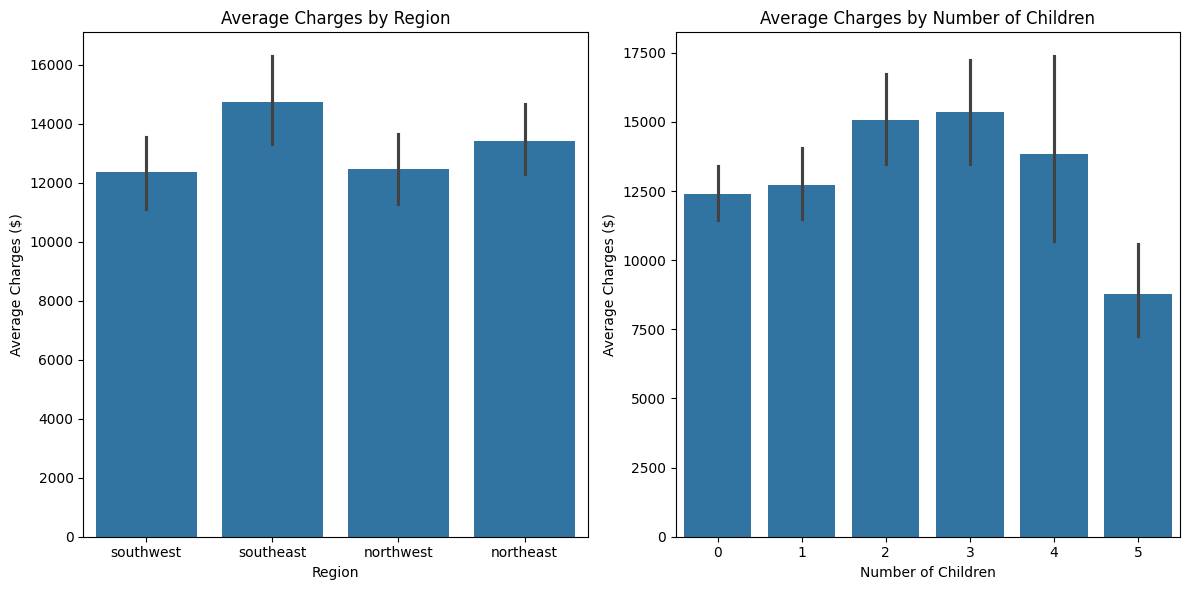

In [29]:
#code structure from Gemini. Copilot suggestions used, Gemini fixes used. 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

sns.barplot(data=df_cleaned, x="region", y="charges", ax=ax1)
ax1.set_title("Average Charges by Region")
ax1.set_ylabel("Average Charges ($)")
ax1.set_xlabel("Region")

sns.barplot(data=df_cleaned, x="children", y="charges", ax=ax2)
ax2.set_title("Average Charges by Number of Children")
ax2.set_ylabel("Average Charges ($)")
ax2.set_xlabel("Number of Children")

plt.tight_layout()
plt.show()

In [ ]:
#check value countss to see sample size for each column before drawing conclusions.
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [31]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

The region barplot shows a similar average across the SOuthwest, Northwest and Northeast, with only the Southeast average being a few thousand dollare higher. In the bar plot on the left, we have different error line sizes and the number of individuals in the data with 4 or 5 children is significantly less that those with 0 children. The average charges remain similar for people with 0-3 children, has a greater error for those with 4 and drops significantly for those with 5 children. However, due to sample size for 4-5 children, the average charge for those columns may be less reliable

Finally, as we saw smoker status to have a great impact on charges, lets see the distribution of charges across all variables, coloured by smoker status.

AI Note: Generative AI was used as a tool to assist in drafting this insight summary based on my visual findings.

### Distribution of Charges Across Variables, Coloured by Smoker:

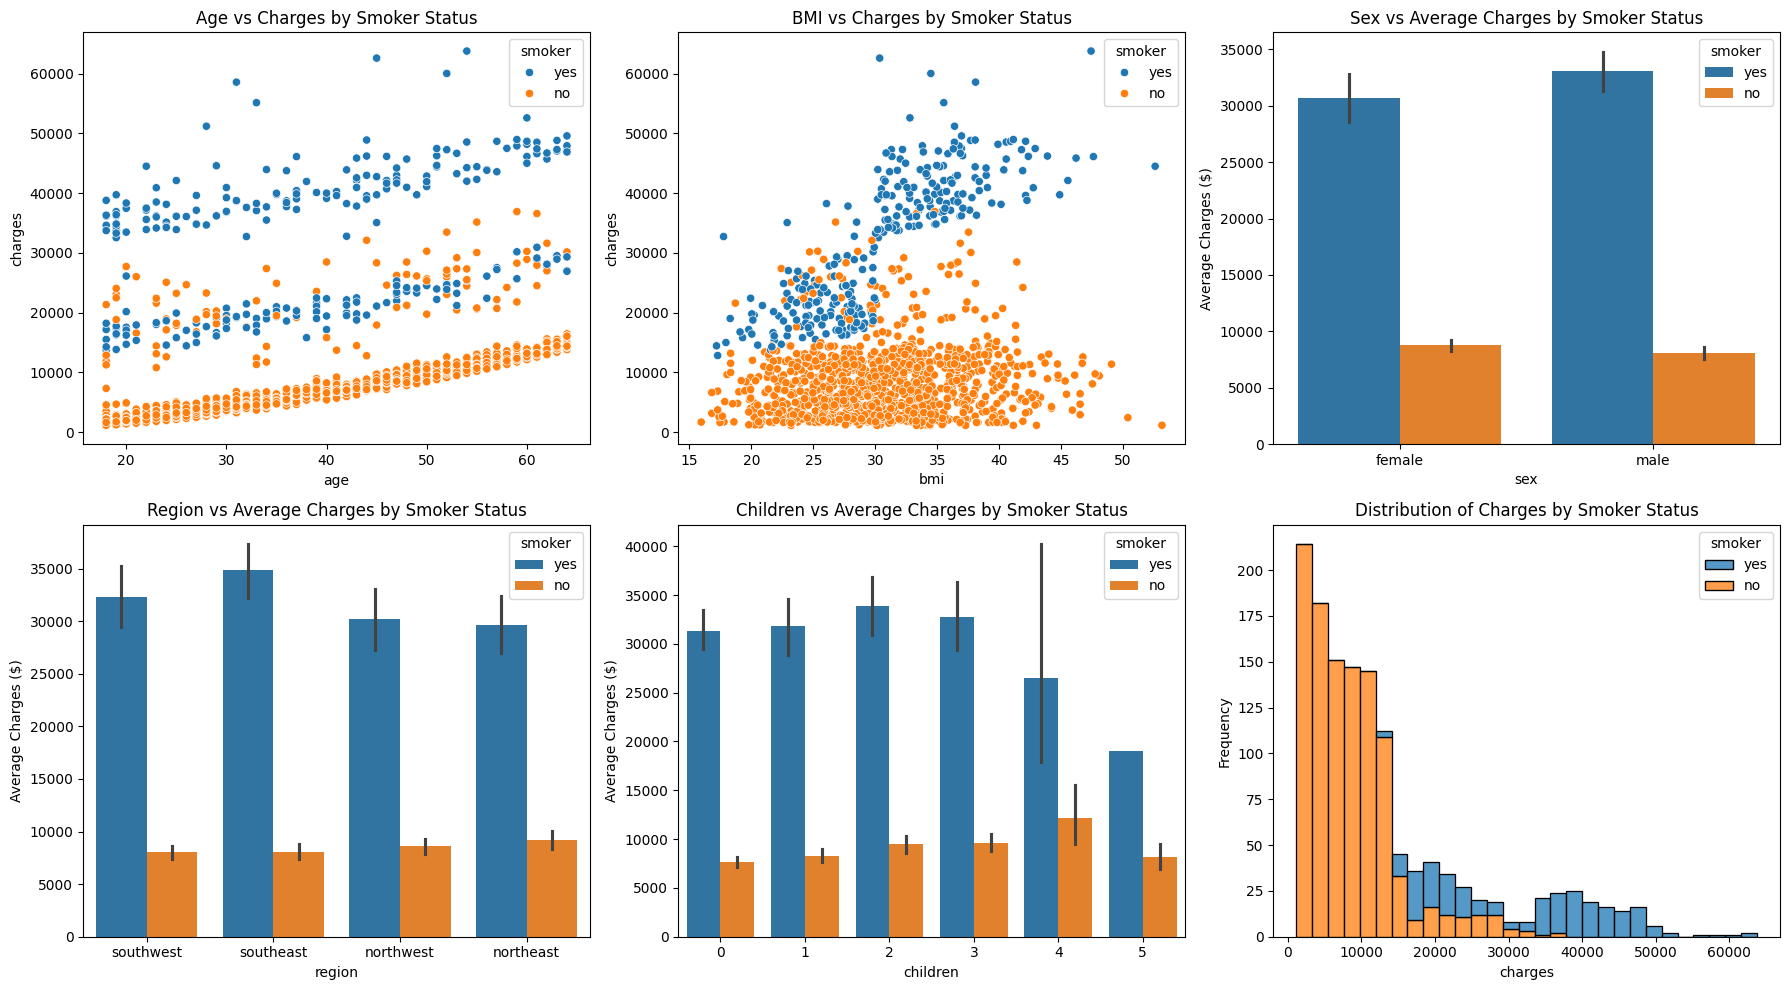

In [33]:
#6 plot grid code copied from Gemini
#Copilot suggestions used to creat each plot and label them.
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(
    nrows=2, ncols=3, figsize=(18, 10)
)
sns.scatterplot(data=df_cleaned, x='age', y='charges', hue='smoker', ax=ax1)
ax1.set_title("Age vs Charges by Smoker Status")

sns.scatterplot(data=df_cleaned, x='bmi', y='charges', hue='smoker', ax=ax2)
ax2.set_title("BMI vs Charges by Smoker Status")

sns.barplot(data=df_cleaned, x='sex', y='charges', hue= 'smoker', ax=ax3)
ax3.set_title("Sex vs Average Charges by Smoker Status")
ax3.set_ylabel("Average Charges ($)")

sns.barplot(data=df_cleaned, x='region', y='charges', hue= 'smoker', ax=ax4)
ax4.set_title("Region vs Average Charges by Smoker Status")
ax4.set_ylabel("Average Charges ($)")

sns.barplot(data=df_cleaned, x='children', y='charges', hue= 'smoker', ax=ax5)
ax5.set_title("Children vs Average Charges by Smoker Status")
ax5.set_ylabel("Average Charges ($)")

sns.histplot(data=df_cleaned, x='charges', hue='smoker', multiple='stack', ax=ax6)
ax6.set_title("Distribution of Charges by Smoker Status")   
ax6.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


This 6 plot figure shows how all variables, split by smoker status, interact with charges. From the bar plots we see that once they are coloured by smoker, the non smoker bars are pretty flat and even, and as we saw earlier, even within the smoker categories, the bar charts do not show definitive trends. Age, BMI and smoking however, have greater influence on the charges, with smoking being the single greatest influential factor, shown in all charts. E.g. The bar charts show that non-smokers by sex, region or number of children are charged around 1/3 or less than 1/3 of what smokers are charged by sex, region and number of children. The final histogram shows that most non-smoker charges lie in the <$15,000 range, whereas smoker charges are spread from around $13,000 / $14,000 - >$50,000.

Note: Generative AI was used to assist in phrasing refinement and structure formatting for these analytical insights.

---

## Conclusions and Next Steps

### Summary of Findings
The final conclusion is that the greatest influencers and categories for predicting healthcare insurance charges are age, BMI and smoker status, with smoker status alone increasing charges, and smoker status combined with higher BMI drastically increasing insurance charges into a price bracket that non-smokers, even those with high BMI, just don't reach.

### Next Steps
1. **Remove Unnecessary Columns:** Leave out sex, region, and number of children when building future models, since they don't help to predict costs.
2. **Build a Prediction Model:** Build a model to automatically estimate insurance costs for new customers based on their age, BMI, and smoking status.
3. **Investigate Regional Smoking:** Given more time, look deeper into whether small regional cost differences are caused by higher smoking rates in certain areas.